<a href="https://colab.research.google.com/github/cwoodhayes/MSAI437_homework/blob/hw2/hw2/hw2_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install datasets

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from textwrap import wrap
from datasets import load_dataset

mydata = load_dataset('valhalla/emoji-dataset')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Filter:   0%|          | 0/2749 [00:00<?, ? examples/s]

100
0
grinning face


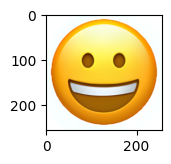

lower resolution


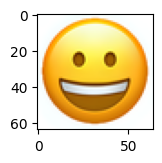

1
smiling face with open mouth


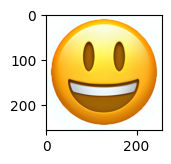

lower resolution


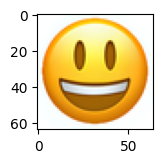

2
winking face


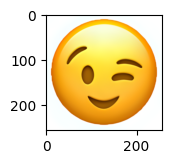

lower resolution


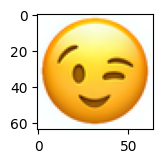

3
robot face


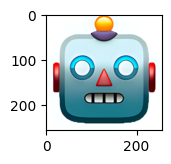

lower resolution


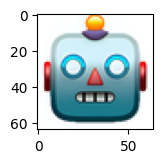

4
smiling cat face with open mouth


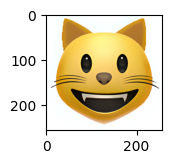

lower resolution


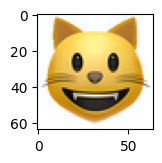

5
grinning cat face with smiling eyes


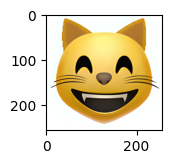

lower resolution


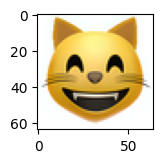

6
cat face with tears of joy


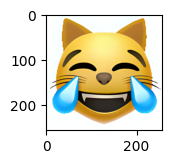

lower resolution


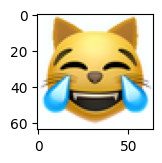

7
smiling cat face with heart shaped eyes


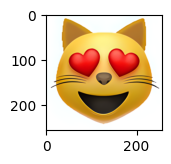

lower resolution


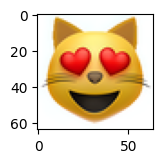

8
cat face with wry smile


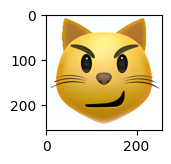

lower resolution


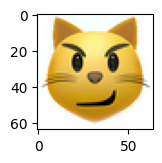

9
kissing cat face with closed eyes


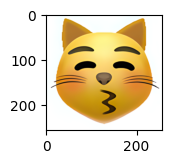

lower resolution


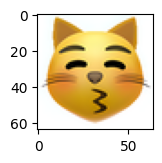

10
weary cat face


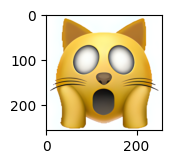

lower resolution


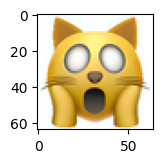

11
crying cat face


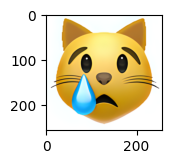

lower resolution


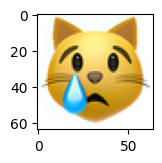

12
smiling face with smiling eyes


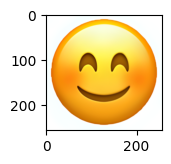

lower resolution


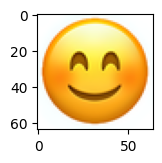

13
smiling face with halo


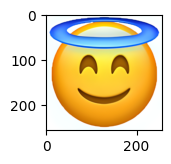

lower resolution


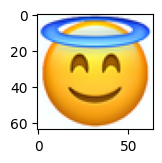

14
smiling face with smiling eyes and three hearts


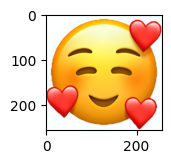

lower resolution


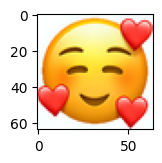

15
smiling face with heart shaped eyes


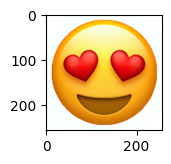

lower resolution


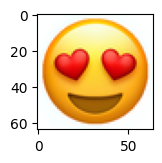

16
grinning face with star eyes


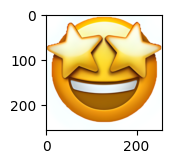

lower resolution


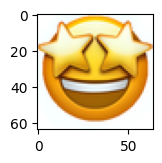

17
cat face


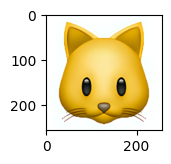

lower resolution


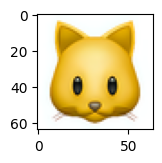

18
tiger face


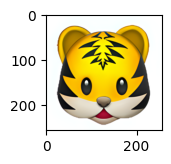

lower resolution


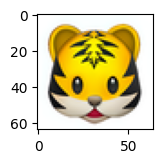

19
face throwing a kiss


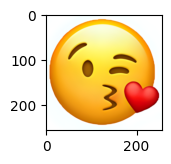

lower resolution


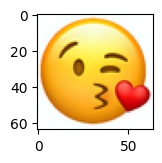

20
kissing face


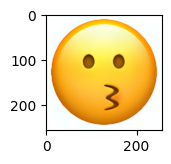

lower resolution


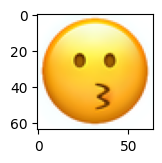

21
white smiling face


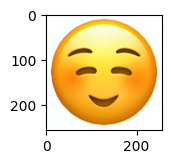

lower resolution


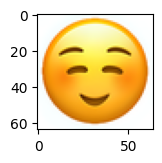

22
kissing face with closed eyes


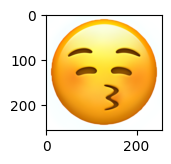

lower resolution


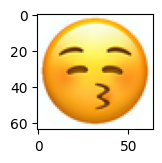

23
sun with face


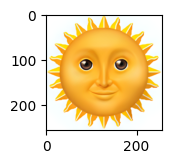

lower resolution


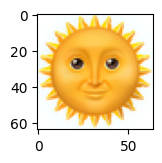

24
smiling face with open mouth and smiling eyes


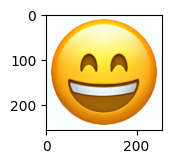

lower resolution


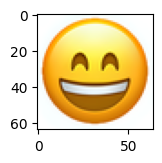

25
kissing face with smiling eyes


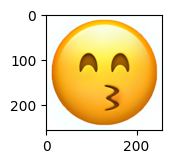

lower resolution


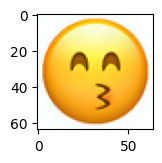

26
face savouring delicious food


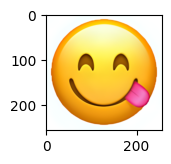

lower resolution


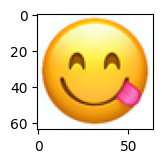

27
face with stuck out tongue


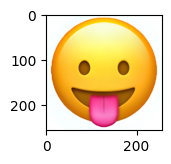

lower resolution


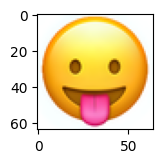

28
face with stuck out tongue and winking eye


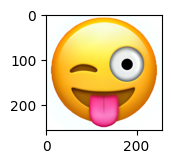

lower resolution


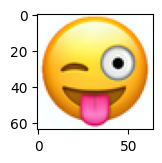

29
grinning face with one large and one small eye


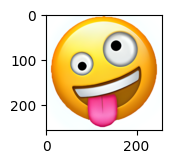

lower resolution


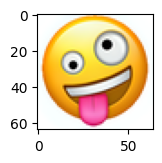

30
face with stuck out tongue and tightly closed eyes


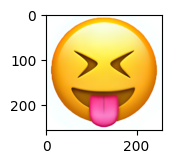

lower resolution


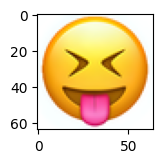

31
money mouth face


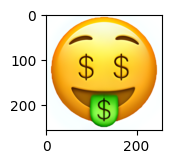

lower resolution


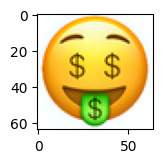

32
hugging face


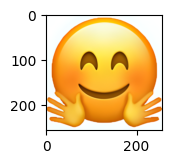

lower resolution


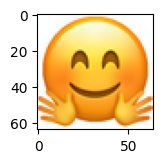

33
smiling face with smiling eyes and hand covering mouth


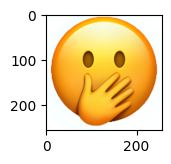

lower resolution


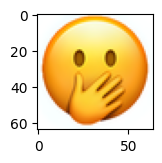

34
face with finger covering closed lips


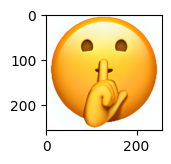

lower resolution


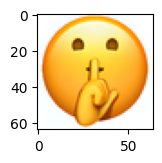

35
grinning face with smiling eyes


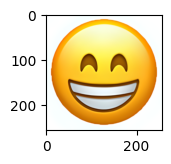

lower resolution


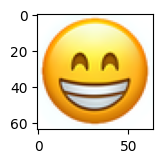

36
thinking face


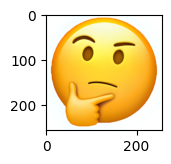

lower resolution


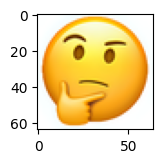

37
zipper mouth face


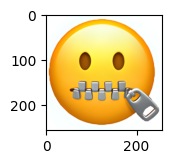

lower resolution


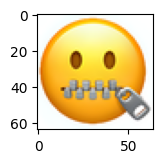

38
face with one eyebrow raised


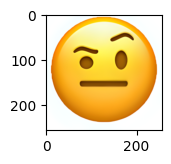

lower resolution


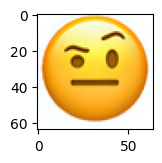

39
neutral face


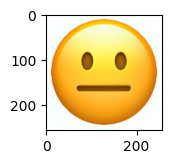

lower resolution


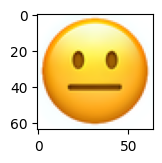

40
expressionless face


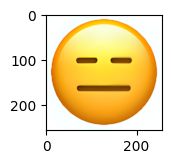

lower resolution


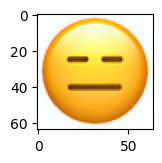

41
face without mouth


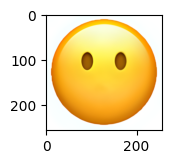

lower resolution


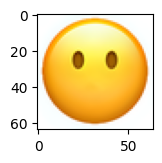

42
smirking face


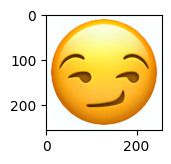

lower resolution


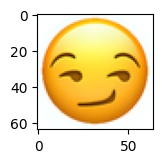

43
unamused face


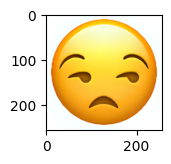

lower resolution


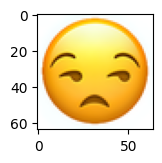

44
face with rolling eyes


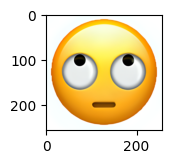

lower resolution


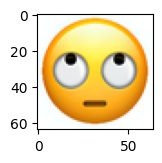

45
grimacing face


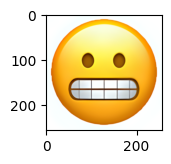

lower resolution


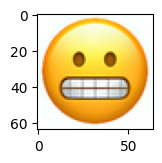

46
smiling face with open mouth and tightly closed eyes


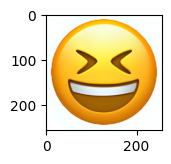

lower resolution


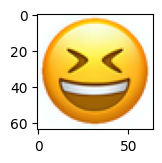

47
lying face


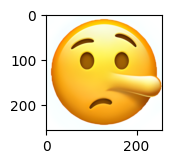

lower resolution


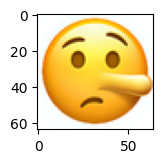

48
relieved face


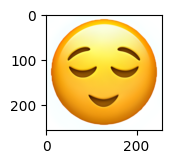

lower resolution


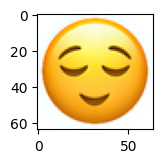

49
pensive face


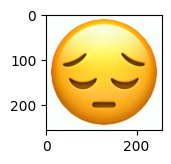

lower resolution


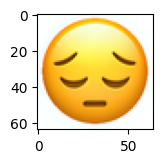

50
sleepy face


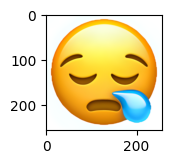

lower resolution


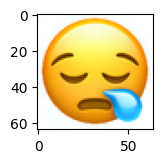

51
drooling face


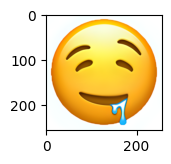

lower resolution


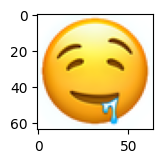

52
sleeping face


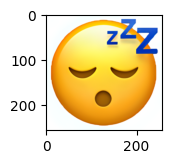

lower resolution


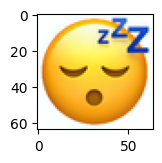

53
face with medical mask


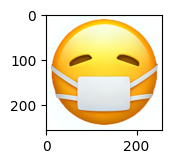

lower resolution


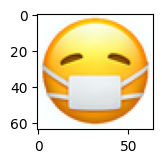

54
face with thermometer


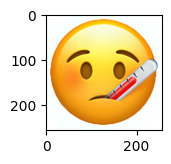

lower resolution


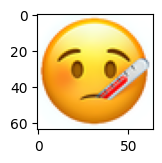

55
face with head bandage


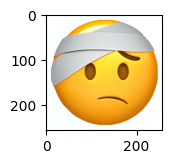

lower resolution


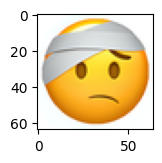

56
nauseated face


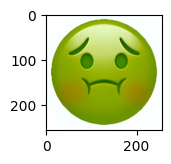

lower resolution


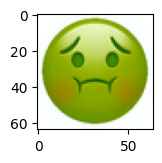

57
smiling face with open mouth and cold sweat


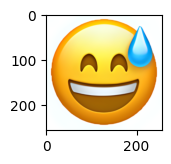

lower resolution


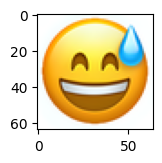

58
face with open mouth vomiting


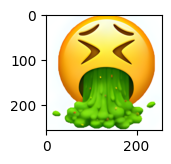

lower resolution


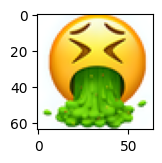

59
sneezing face


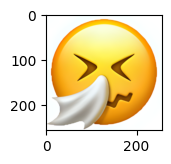

lower resolution


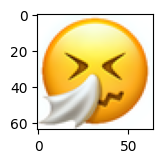

60
overheated face


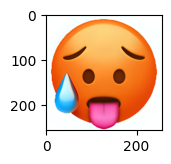

lower resolution


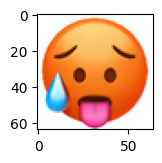

61
freezing face


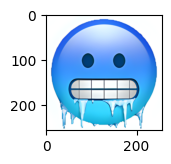

lower resolution


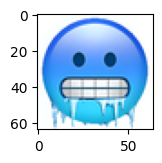

62
face with uneven eyes and wavy mouth


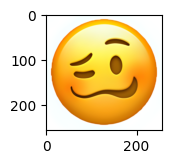

lower resolution


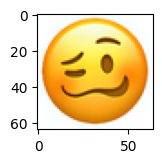

63
dizzy face


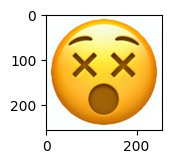

lower resolution


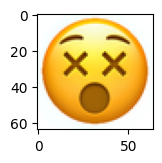

64
shocked face with exploding head


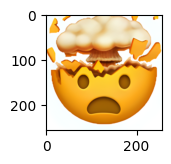

lower resolution


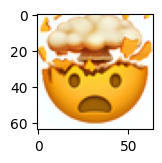

65
face with party horn and party hat


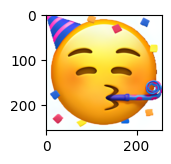

lower resolution


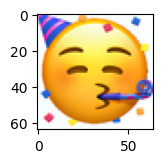

66
smiling face with sunglasses


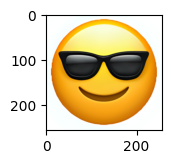

lower resolution


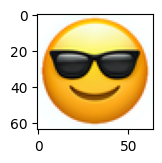

67
nerd face


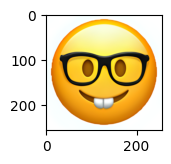

lower resolution


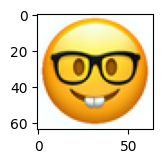

68
face with monocle


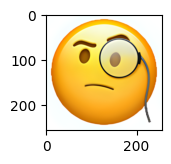

lower resolution


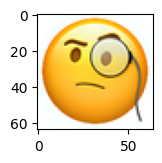

69
confused face


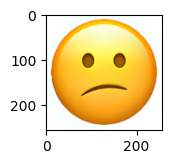

lower resolution


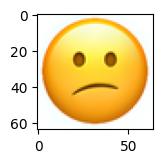

70
worried face


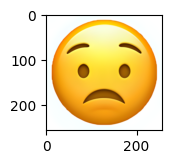

lower resolution


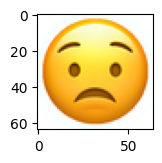

71
slightly frowning face


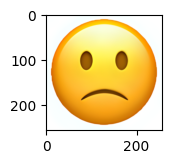

lower resolution


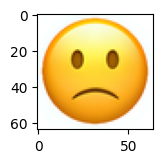

72
white frowning face


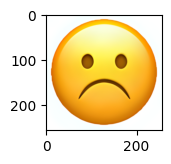

lower resolution


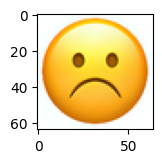

73
face with open mouth


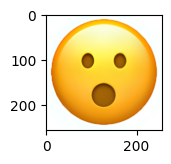

lower resolution


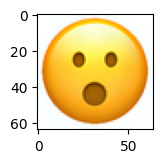

74
hushed face


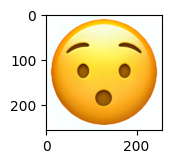

lower resolution


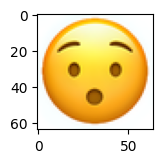

75
astonished face


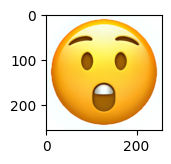

lower resolution


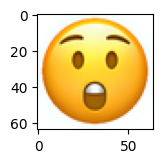

76
flushed face


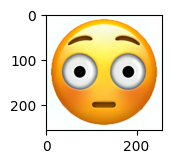

lower resolution


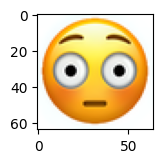

77
face with tears of joy


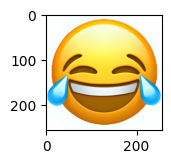

lower resolution


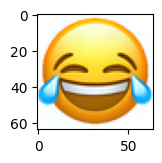

78
face with pleading eyes


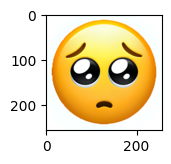

lower resolution


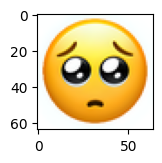

79
frowning face with open mouth


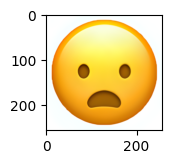

lower resolution


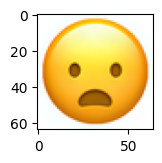

80
anguished face


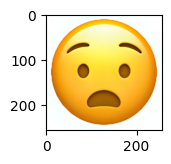

lower resolution


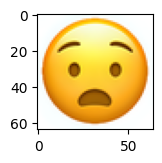

81
fearful face


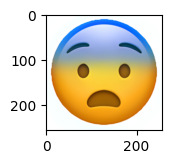

lower resolution


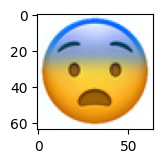

82
face with open mouth and cold sweat


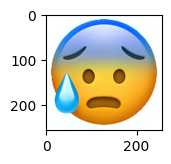

lower resolution


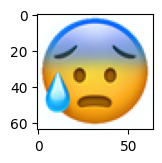

83
disappointed but relieved face


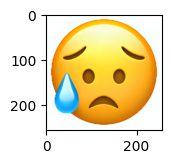

lower resolution


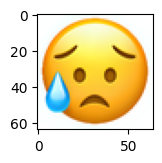

84
crying face


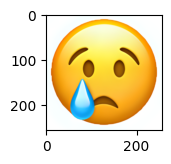

lower resolution


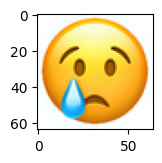

85
loudly crying face


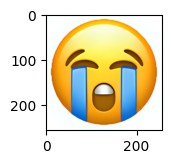

lower resolution


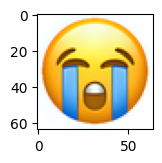

86
face screaming in fear


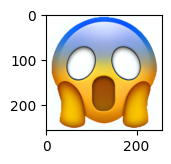

lower resolution


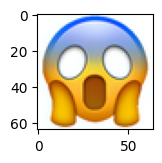

87
confounded face


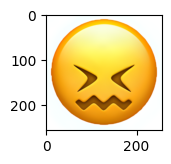

lower resolution


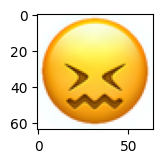

88
slightly smiling face


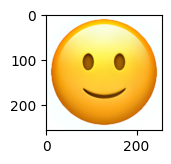

lower resolution


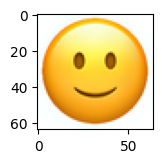

89
persevering face


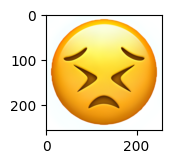

lower resolution


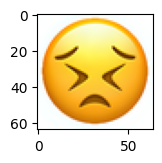

90
disappointed face


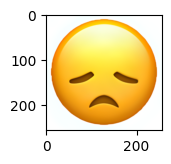

lower resolution


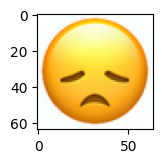

91
face with cold sweat


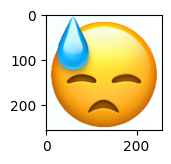

lower resolution


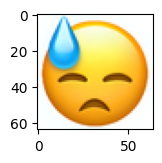

92
weary face


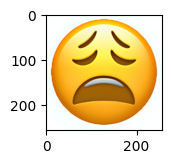

lower resolution


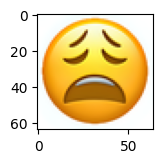

93
tired face


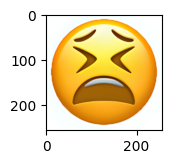

lower resolution


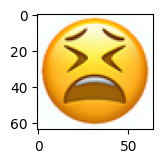

94
face with look of triumph


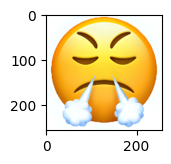

lower resolution


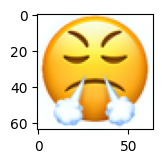

95
angry face


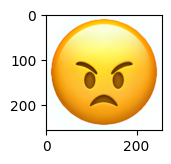

lower resolution


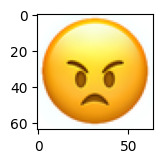

96
serious face with symbols covering mouth


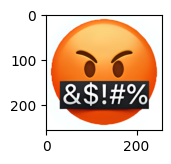

lower resolution


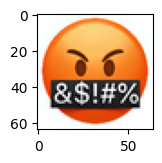

97
smiling face with horns


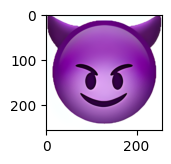

lower resolution


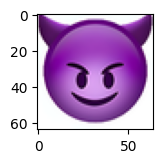

98
upside down face


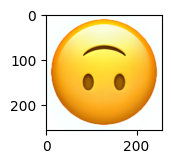

lower resolution


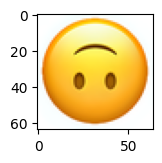

99
clown face


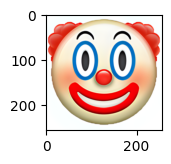

lower resolution


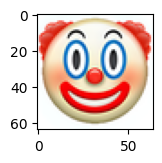

In [2]:
# include_keywords = ['face','christmas','superhero','supervillian','mage','vampire','monkey','elf','juggling',
#             'boy','girl','adult','person','man','woman','male','female','worker','scientist','technologist',
#             'singer','artist','pilot','astronaut','firefighter','police','sleuth','construction']
include_keywords = ['face']

exclude_keywords = ["clock", "gesture", "moon", "palm", "massage", "wind", "pout",
                    "mouse", "lion", "dragon", "giraffe", "monkey", "dog", "cow", "horse",
                    "zebra", "wolf", "fox", "pig", "rabbit", "panda", "hamster",
                    "bear", "unicorn", "frog"]

def keep_row(example):
    title = (example.get("text") or "").lower()

    inc = any(k.lower() in title for k in include_keywords) if include_keywords else True
    exc = any(k.lower() in title for k in exclude_keywords) if exclude_keywords else False

    return inc and not exc


plt.rcParams["figure.figsize"] = [1.5, 1.50]

mydata = load_dataset('valhalla/emoji-dataset')
mydata = mydata.filter(keep_row)
print(len(mydata['train']))
total_obs = len(mydata['train'])
data = np.zeros([total_obs,3,64,64],dtype='float32')
for i in range(total_obs):
    print(i)
    im = mydata['train'][i]['image']
    title = mydata['train'][i]['text']
    plt.imshow(im)
    print(title)
    plt.show()

    im = im.resize((64,64),Image.LANCZOS)
    title = "lower resolution"
    plt.imshow(im)
    print(title)
    plt.show()
    pix = im.load()
    for x in range(im.size[0]):
        for y in range(im.size[1]):
            for c in range(3):
                data[i,c,x,y] = float(pix[x,y][c]) / 255.0

In [7]:
train_val_test_dataset = mydata['train'].train_test_split(test_size=0.4, seed=42)
val_test_dataset = train_val_test_dataset['test'].train_test_split(test_size=0.5, seed=42)

train_dataset = train_val_test_dataset['train']
val_dataset = val_test_dataset['train']
test_dataset = val_test_dataset['test']

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"First training row: {train_dataset[0]}")

Training set size: 60
Validation set size: 20
Test set size: 20
First training row: {'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=256x256 at 0x7C5BC1663B60>, 'text': 'face with cold sweat'}
